In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
from bct.utils.other import threshold_proportional, normalize
from small_world_propensity import SWP, characteristic_path_length, clustering_coefficient_bct
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler

In [3]:
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/covariance_symmetrized.npy')
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')

In [2]:
spi_dir = '/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/'
sc_dir = '/home/gbz6qn/Documents/research/data/hcp_shen_sc/'
# List of subs
with open('/home/gbz6qn/Documents/research/code/coupling/compute_gca/subs.txt', 'r') as f:
    lines = f.read()
    subs = lines.split('\n')[:-1]
subs = sorted(subs)

In [3]:
# Load in all subjects into stacked array
all_subs = []
for sub in subs:
    fc_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
    fc_raw = np.load(fc_path)
    fc = np.abs(fc_raw)
    all_subs.append(fc)
stacked = np.stack(all_subs)

## Thresholding by only retaining edges that also exist in the structural connectivity matrix

In [46]:
SWP_cov = []
delta_C_cov = []
delta_L_cov = []

for i, sub in tqdm(enumerate(subs)):
    fc_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
    sc_path = os.path.join(sc_dir, f'sub-{sub}_parc-shen268_tract-prob_sc.npy')

    fc = np.load(fc_path)
    sc = np.load(sc_path)

    sparser = fc*(sc!=0)
    swp, delta_C, delta_L = SWP(sparser)
    SWP_cov.append(swp)
    delta_C_cov.append(delta_C)
    delta_L_cov.append(delta_L)

SWP_fc = np.array(SWP_cov)
SWP_fc = np.mean(SWP_fc[~np.isnan(SWP_fc)])
delta_C_fc = np.array(delta_C_cov)
delta_C_fc = np.mean(delta_C_fc[~np.isnan(delta_C_fc)])
delta_L_fc = np.array(delta_L_cov)
delta_L_fc = np.mean(delta_L_fc[~np.isnan(delta_L_fc)])

329it [03:53,  1.41it/s]


In [47]:
print(f'SWP: {SWP_fc:.3f}, delta_C: {delta_C_fc:.3f}, delta_L: {delta_L_fc}')

SWP: 0.585, delta_C: 0.311, delta_L: 0.4496801512197063


## Threshold using proportional thresholding at various levels
I want to examine how clustering, path length, and SWP change at the various levels

In [8]:
def consensus_threshold(matrices, rho, x_pct) -> np.ndarray:
    """
    Consensus thresholding on a stack of adjacency matrices.

    Parameters
    ----------
    matrices : np.ndarray, shape (n_subjects, n_nodes, n_nodes)
        Stack of weighted adjacency matrices with edge weights in [0, 1].
    rho : float
        Minimum edge weight to count as "present" in a subject.
    x_pct : float
        Minimum fraction of subjects (in [0, 1]) that must have the edge
        above rho for it to be retained. E.g. 0.5 = 50%.

    Returns
    -------
    consensus_mask : np.ndarray, shape (n_nodes, n_nodes)
        Binary consensus mask (1 = retained, 0 = eliminated).
    mean_matrix_threshold : np.ndarray, shape (n_nodes, n_nodes)
        Mean weight matrix masked by consensus (useful as a weighted output).
    """
    n_subjects = matrices.shape[0]

    # Step 1: binarize each subject's matrix at threshold rho
    # (n_subjects, n_nodes, n_nodes)
    present = (matrices >= rho)

    # Step 2: fraction of subjects with edge above rho
    prevalence = present.mean(axis=0)

    # Step 3: retain edges meeting the consensus criterion
    consensus_mask = (prevalence >= x_pct)

    # Step 4: apply mask to mean weights (common output format)
    mean_matrix = matrices.mean(axis=0)
    mean_matrix_thresholded = mean_matrix * consensus_mask

    return consensus_mask, mean_matrix_thresholded

In [44]:
mask, thresholded = consensus_threshold(stacked, 0.2, 0.5)

In [45]:
nx.is_connected(nx.Graph(thresholded))

False

<Axes: >

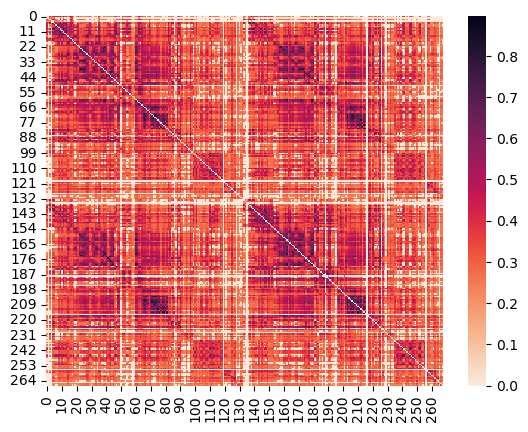

In [46]:
sns.heatmap(thresholded, cmap='rocket_r')

In [4]:
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results = {t: {'clustering': [], 'path_length': [], 'swp': []} for t in thresholds}
# Loop over each threshold
for _, threshold in tqdm(enumerate(thresholds)):
    # Loop over each subject
    for i in range(stacked.shape[0]):
        # Threshold at current level
        adj = np.where(stacked[i] >= threshold, stacked[i], 0)
        c = clustering_coefficient_bct(adj)
        l = characteristic_path_length(adj)
        swp, _, _ = SWP(adj)
        results[threshold]['clustering'].append(c)
        results[threshold]['path_length'].append(l)
        results[threshold]['swp'].append(swp)


0it [01:37, ?it/s]


KeyboardInterrupt: 

In [5]:
results

{0.05: {'clustering': [np.float64(0.27405647622541446),
   np.float64(0.32524232056515173),
   np.float64(0.47740875411654526),
   np.float64(0.342207251454471),
   np.float64(0.3080670763645972),
   np.float64(0.5559741178790831),
   np.float64(0.41526078850585374),
   np.float64(0.38265551110340973),
   np.float64(0.42578701703182265),
   np.float64(0.23094864144597366),
   np.float64(0.203910076073031),
   np.float64(0.20387169824165152),
   np.float64(0.490144577309394),
   np.float64(0.23373658901589067),
   np.float64(0.25423496100427595),
   np.float64(0.1738736572905901),
   np.float64(0.354925966077899),
   np.float64(0.2080761822303806),
   np.float64(0.5035577474330155),
   np.float64(0.38530839900778485),
   np.float64(0.25813435253417594),
   np.float64(0.46832773017272633),
   np.float64(0.4144420867673989),
   np.float64(0.3199176869208604),
   np.float64(0.5087309930610775),
   np.float64(0.22878192389902366),
   np.float64(0.37552599961469324),
   np.float64(0.40724379